# Calc Offset v1
Load car parquet data with selected columns

In [1]:
import pandas as pd
import json
import os
from glm_model_test import load_glm_model, predict_glm
from default_value_handler import check_missing_values, apply_all_defaults

In [19]:

debug_folder = '/Users/Mach/dev/aps/data/2026_Dmodel_data/debug/'
bsst = 'Entry_Level_Car_GLM'
debug_car_with_dep_factor = debug_folder + f'Records_{bsst}.parquet'
df_dep_fact = pd.read_parquet(debug_car_with_dep_factor)
print(f"Data loaded successfully! Shape: {df_dep_fact.shape}")
df_dep_fact.head()


Data loaded successfully!


,cef_est_curr_mi_grp_imps,zip_pop_dens,dml_year_imps,vc_msrp_impa,st_raw,insstate,dml_make_raw,vin,vin_date,zip,...,MAKE_DAIHATSU,MAKE_ISUZU,MAKE_SUBARU,MAKE_MAZDA,MAKE_DATSUN,MAKE_PONTIAC,MAKE_DAEWOO,MAKE_BUICK,MAKE_DODGE,MAKE_CHRYSLER
0,10000.0,11.136200,2017.0,15745.0,NM,NM,HYUNDAI,KMHCT4AE3HU248121,KMHCT4AE3HU248121_02-11-2020,88201,...,False,False,False,False,False,False,False,False,False,False
1,10000.0,68.004925,2018.0,16385.0,IN,IN,TOYOTA,VNKJTUD32JA092822,VNKJTUD32JA092822_12-28-2021,47106,...,False,False,False,False,False,False,False,False,False,False
2,6402.0,28.033923,2024.0,16695.0,AR,AR,MITSUBISHI,ML32AUHJ2RH009231,ML32AUHJ2RH009231_10-01-2024,72927,...,False,False,False,False,False,False,False,False,False,False
3,10000.0,77.603542,2016.0,16555.0,WV,WV,TOYOTA,VNKJTUD33GA060714,VNKJTUD33GA060714_05-13-2019,26452,...,False,False,False,False,False,False,False,False,False,False
4,10000.0,26.471183,2018.0,17660.0,OK,OK,TOYOTA,VNKKTUD35JA099171,VNKKTUD35JA099171_01-01-2021,73077,...,False,False,False,False,False,False,False,False,False,False


In [2]:
# Load GLM model for this BSST segment
bsst_glm_path = '/Users/Mach/dev/aps/data/2026_Dmodel_data/BSST_json'
model_path = os.path.join(bsst_glm_path, f"{bsst}.json")

with open(model_path, 'r') as f:
    glm_model = json.load(f)
    
print(f"Loaded GLM model: {glm_model['model_name']}")
print(f"Number of coefficients: {len(glm_model['coefficients'])}")

Parquet path: /Users/Mach/dev/aps/data/2026_Dmodel_data/master_dataset_car.parquet
Parquet path: data/2026_Dmodel_data/master_dataset_car.parquet
vin_bsst_path path: /Users/Mach/dev/aps/data/2026_Dmodel_data/VIN_BSST.parquet
Parquet path: data/2026_Dmodel_data/VIN_BSST.parquet
BSST GLM path: /Users/Mach/dev/aps/data/2026_Dmodel_data/BSST_json
car_with_dep_factor path: /Users/Mach/dev/aps/data/2026_Dmodel_data/car_with_dep_factor.parquet


In [ ]:
# Run predictions on the debug data
predictions = predict_glm(df_dep_fact, glm_model)

# Add predictions to df_dep_fact for comparison
df_dep_fact['Dep_factor_recalc'] = predictions.values

print(f"Predictions computed for {len(predictions):,} records")
print(f"\nOriginal Dep_factor stats:")
print(df_dep_fact['Dep_factor'].describe())
print(f"\nRecalculated Dep_factor stats:")
print(df_dep_fact['Dep_factor_recalc'].describe())

In [ ]:
# Compare original vs recalculated
df_dep_fact[['ODOMETER', 'geo_pop_density_ntile', 'CALC_VEH_AGE', 'Dep_factor', 'Dep_factor_recalc']].head(10)

In [2]:
# Load config
with open('config.json', 'r') as f:
    config = json.load(f)

parquet_path = config['car_parquet_path']
print(f"Parquet path: {parquet_path}")
short_path = '/'.join(parquet_path.split('/')[-3:])
print(f"Parquet path: {short_path}")

vin_bsst_path = config['vin_bsst_path']
print(f"vin_bsst_path path: {vin_bsst_path}")
short_vin_bsst_path = '/'.join(vin_bsst_path.split('/')[-3:])
print(f"Parquet path: {short_vin_bsst_path}")

# Load BSST_GLM_path from config
bsst_glm_path = config['BSST_GLM_path']
print(f"BSST GLM path: {bsst_glm_path}")

car_with_dep_factor = config['car_with_dep_factor']
print(f"car_with_dep_factor path: {car_with_dep_factor}")





In [3]:
# Load parquet file with selected columns
df_dep_fact = pd.read_parquet(car_with_dep_factor)
print(f"Data loaded successfully!")

Data loaded successfully!


In [4]:
df_dep_fact.head()

,vin_date,vin,BSST,ODOMETER,ODOMETER_IMP_FLAG,CALC_VEH_AGE,STATE,vc_msrp_impa,Dep_factor,veh_value_dep
0,KMHWF35H45A178516_04-26-2022,KMHWF35H45A178516,Lower Midsize (Car),101755.0,1,20.0,OH,19594.0,0.046729,915.600315
1,KMHWF35H75A128502_11-21-2020,KMHWF35H75A128502,Lower Midsize (Car),210000.0,0,20.0,TX,19594.0,0.030050,588.801229
2,KMHD35LE5DU068088_05-03-2020,KMHD35LE5DU068088,Basic Economy (Car),70000.0,0,12.0,CA,19545.0,0.533177,10420.937286
3,KMHD35LE5DU047158_05-30-2021,KMHD35LE5DU047158,Basic Economy (Car),60000.0,0,12.0,GA,18545.0,0.415157,7699.095568
4,KMHD35LE5DU082332_11-17-2019,KMHD35LE5DU082332,Basic Economy (Car),56573.0,1,12.0,NJ,18545.0,0.204333,3789.349329


In [8]:
df_dep_fact.describe()

,ODOMETER,ODOMETER_IMP_FLAG,CALC_VEH_AGE,vc_msrp_impa,Dep_factor,veh_value_dep
count,2.705582e+07,2.705582e+07,2.705582e+07,2.705582e+07,2.703474e+07,2.703474e+07
mean,8.703052e+04,3.811373e-01,1.404795e+01,2.693288e+04,2.328350e+20,4.018383e+25
std,5.522440e+04,4.856662e-01,3.544474e+01,1.284091e+04,4.280202e+23,7.386986e+28
min,1.918000e+03,0.000000e+00,0.000000e+00,0.000000e+00,1.543989e-41,0.000000e+00
25%,4.743000e+04,0.000000e+00,9.000000e+00,1.979500e+04,1.677950e-01,3.800249e+03
50%,7.593000e+04,0.000000e+00,1.300000e+01,2.384000e+04,3.105602e-01,7.439158e+03
75%,1.200000e+05,1.000000e+00,1.800000e+01,3.000500e+04,5.001195e-01,1.304980e+04
max,1.020000e+06,1.000000e+00,3.024000e+03,9.589660e+05,7.868290e+26,1.357949e+32


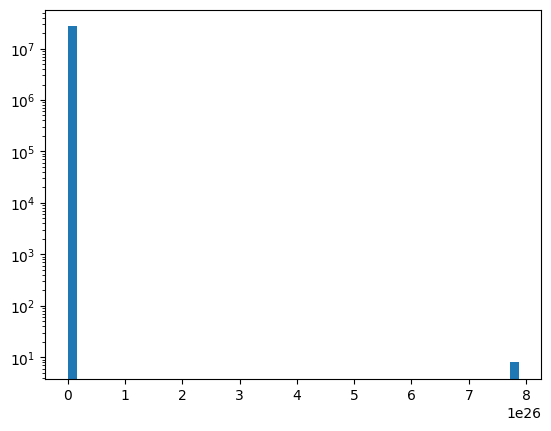

In [5]:
import matplotlib.pyplot as plt
plt.hist(df_dep_fact['Dep_factor'], log = 1, bins=50);

<Axes: >

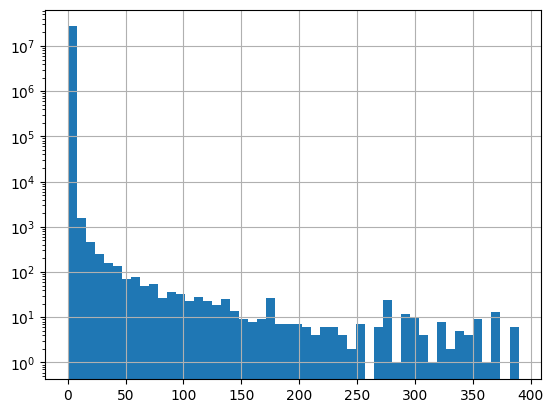

In [11]:
# Histogram without extreme outliers
df_dep_fact[df_dep_fact['Dep_factor'] < 400]['Dep_factor'].hist(bins=50, log = 1)


In [8]:
df_dep_fact[df_dep_fact['Dep_factor'] < 100].describe()

,ODOMETER,ODOMETER_IMP_FLAG,CALC_VEH_AGE,vc_msrp_impa,Dep_factor,veh_value_dep
count,2.703365e+07,2.703365e+07,2.703365e+07,2.703365e+07,2.703365e+07,2.703365e+07
mean,8.701334e+04,3.811053e-01,1.364573e+01,2.692764e+04,3.537180e-01,1.027681e+04
std,5.521654e+04,4.856584e-01,6.732248e+00,1.280994e+04,3.986425e-01,3.721757e+04
min,1.918000e+03,0.000000e+00,0.000000e+00,0.000000e+00,1.543989e-41,0.000000e+00
25%,4.743000e+04,0.000000e+00,9.000000e+00,1.979500e+04,1.677883e-01,3.800104e+03
50%,7.593000e+04,0.000000e+00,1.300000e+01,2.384000e+04,3.105485e-01,7.438820e+03
75%,1.200000e+05,1.000000e+00,1.800000e+01,3.000500e+04,5.000921e-01,1.304901e+04
max,1.020000e+06,1.000000e+00,3.024000e+03,9.589660e+05,9.923418e+01,2.814078e+07


In [ ]:
df_dep_fact[df_dep_fact['Dep_factor'] < 1e26].sum()

In [17]:
# Count rows where Dep_factor > 1
count = (df_dep_fact['Dep_factor'] > 1e26).sum()
print(f"Number of rows where Dep_factor > 1: {count}")


Number of rows where Dep_factor > 1: 8


In [16]:
# Count rows where Dep_factor > 1
count = (df_dep_fact['Dep_factor'] > 5).sum()
print(f"Number of rows where Dep_factor > 5: {count}")

Number of rows where Dep_factor > 5: 5724


In [18]:
df_filtered = df_dep_fact[df_dep_fact['Dep_factor']  > 1e26]
df_filtered.head()

,vin_date,vin,BSST,ODOMETER,ODOMETER_IMP_FLAG,CALC_VEH_AGE,STATE,vc_msrp_impa,Dep_factor,veh_value_dep
226349,SCBCR73W87C043637_07-18-2022,SCBCR73W87C043637,Prestige Luxury (Car),10000.0,0,18.0,NY,172585.0,7.868290e+26,1.357949e+32
5471291,SCBCR73W87C043637_01-18-2021,SCBCR73W87C043637,Prestige Luxury (Car),10000.0,0,18.0,NY,172585.0,7.868290e+26,1.357949e+32
8858250,SCBCR73W87C043637_07-18-2023,SCBCR73W87C043637,Prestige Luxury (Car),10000.0,0,18.0,NY,172585.0,7.868290e+26,1.357949e+32
10870169,SCBCR73W87C043637_07-18-2021,SCBCR73W87C043637,Prestige Luxury (Car),10000.0,0,18.0,NY,172585.0,7.868290e+26,1.357949e+32
13996168,SCBCR73W87C043637_07-18-2020,SCBCR73W87C043637,Prestige Luxury (Car),10000.0,0,18.0,NY,172585.0,7.868290e+26,1.357949e+32


In [17]:
df_filtered = df_dep_fact[df_dep_fact['Dep_factor']  > 100]
df_filtered.head()

,vin_date,vin,BSST,ODOMETER,ODOMETER_IMP_FLAG,CALC_VEH_AGE,STATE,vc_msrp_impa,Dep_factor,veh_value_dep
170070,SAJWA6BU2H8K42006_11-06-2023,SAJWA6BU2H8K42006,Prestige Sporty (Car),60000.0,0,8.0,CA,80600.0,104.963948,8.460094e+06
174978,SCBCR63W55C025412_11-20-2022,SCBCR63W55C025412,Prestige Luxury (Car),101755.0,1,20.0,NJ,158585.0,180.156037,2.857005e+07
176144,SCBCG2ZG8LC075250_08-31-2020,SCBCG2ZG8LC075250,Prestige Luxury (Car),36200.0,1,5.0,CA,202500.0,14760.987731,2.989100e+09
176166,SCCLMDVN2JHA11244_02-25-2020,SCCLMDVN2JHA11244,Prestige Sporty (Car),40654.0,1,7.0,CA,94900.0,352.602636,3.346199e+07
189595,TRUBFAFK3C1006305_04-05-2021,TRUBFAFK3C1006305,Prestige Sporty (Car),30000.0,0,13.0,IL,38300.0,232.268795,8.895895e+06


In [19]:
df_dep_fact['BSST'].value_counts()['Prestige Luxury (Car)']



np.int64(3584)

In [20]:
df_dep_fact[df_dep_fact['BSST'] == 'Prestige Luxury (Car)'].head()



,vin_date,vin,BSST,ODOMETER,ODOMETER_IMP_FLAG,CALC_VEH_AGE,STATE,vc_msrp_impa,Dep_factor,veh_value_dep
174197,SCA665C53GUX86092_02-01-2021,SCA665C53GUX86092,Prestige Luxury (Car),10000.0,0,9.0,FL,304350.0,2.279905,693889.123373
174233,SCBGT3ZA4EC040903_09-01-2019,SCBGT3ZA4EC040903,Prestige Luxury (Car),53887.0,1,11.0,FL,195200.0,0.464368,90644.541493
174281,SCBDR33W08C055280_06-23-2024,SCBDR33W08C055280,Prestige Luxury (Car),120000.0,0,17.0,CA,193990.0,0.282406,54783.916114
174282,SCBCG2ZG0MC090245_01-08-2023,SCBCG2ZG0MC090245,Prestige Luxury (Car),30059.0,1,4.0,IN,202500.0,2.834510,573988.256510
174283,SCBCG2ZG0MC090245_01-08-2023,SCBCG2ZG0MC090245,Prestige Luxury (Car),30059.0,1,4.0,IN,202500.0,2.834510,573988.256510


In [ ]:
# Define columns to load
columns = [
    'cef_est_curr_mi_grp_imps', # 'odometer',
    'zip_pop_dens',#'geo_pop_density_ntile',
    'dml_year_imps', #'CALC_VEH_AGE',
    'vc_msrp_impa',
    'st_raw',
    'insstate',
    'dml_make_raw',
    'vin',
    'vin_date', 
    'zip'
]

# Load parquet file with selected columns
df = pd.read_parquet(parquet_path, columns=columns)
print(f"Data loaded successfully!")

In [ ]:
# Display basic info
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData types:")
print(df.dtypes)

In [ ]:
# Preview data
df.head()

In [ ]:
# Count records where cef_est_curr_mi_grp_imps = 0
zero_count = (df['cef_est_curr_mi_grp_imps'] == 0).sum()
total_count = len(df)
print(f"Records with cef_est_curr_mi_grp_imps = 0: {zero_count:,}")
print(f"Total records: {total_count:,}")
print(f"Percentage: {zero_count/total_count*100:.2f}%")



In [ ]:
odo_median = df['cef_est_curr_mi_grp_imps'].median()
print(odo_median) 

In [ ]:
# Load VIN_BSST parquet file
df_bsst = pd.read_parquet(vin_bsst_path, columns=['VIN', 'BODY_STYLE_SEGMENT_BODY_TYPE'])
print(f"VIN_BSST loaded: {df_bsst.shape}")
df_bsst.head()

In [ ]:
# Merge BODY_STYLE_SEGMENT_BODY_TYPE to df using VIN
df = df.merge(df_bsst, left_on='vin', right_on='VIN', how='left')
print(f"After merge shape: {df.shape}")

In [ ]:
# Create BSST_formatted column
# Transform: "Basic Economy (Car)" -> "Basic_Economy_Car_GLM"
df['BSST_formatted'] = (df['BODY_STYLE_SEGMENT_BODY_TYPE']
    .str.replace(' ', '_')
    .str.replace('_(', '_', regex=False)
    .str.replace(')', '', regex=False) + '_GLM')

# Preview the formatting
print("Sample BSST_formatted values:")
print(df[['BODY_STYLE_SEGMENT_BODY_TYPE', 'BSST_formatted']].drop_duplicates().head(10))

In [ ]:
# Get unique BSST_formatted values
unique_bsst = df['BSST_formatted'].dropna().unique()
print(f"Found {len(unique_bsst)} unique BSST_formatted values:")
for bsst in sorted(unique_bsst):
    print(f"  - {bsst}")

## Data Quality Check - Missing Values
Check for zeros, nulls, empty strings for key features before applying defaults

In [ ]:
# Check missing values BEFORE applying defaults
print("Model Year from config:", config['model_year'])
missing_summary_before = check_missing_values(df, config['model_year'])

## Apply Default Values
Fill missing values using lookup tables:
- **Odometer**: Lookup by vehicle age (ages > 25 use age 25 default)
- **State**: Lookup by BSST (Body Style Segment Body Type)
- **Population Density Percentile**: Use 50 (median) as default

In [ ]:
# Apply all default values
df, fill_counts = apply_all_defaults(df, config)

In [ ]:
# Check missing values AFTER applying defaults
missing_summary_after = check_missing_values(df, config['model_year'])

## Process Full Data - GLM Predictions
Run GLM predictions for ALL BSST segments and combine results

In [ ]:
def prepare_and_predict(df_segment, glm_model, model_year):
    """
    Prepare data for GLM model and run predictions for a single BSST segment.
    
    Parameters:
    -----------
    df_segment : pd.DataFrame
        Data filtered for a specific BSST segment
    glm_model : dict
        Loaded GLM model configuration
    model_year : int
        Model year for calculating vehicle age
        
    Returns:
    --------
    pd.Series
        Predictions (Dep_factor) for all records in the segment
    """
    df_pred = df_segment.copy()
    
    # Map columns to GLM model expected names
    df_pred['ODOMETER'] = df_pred['cef_est_curr_mi_grp_imps']
    df_pred['geo_pop_density_ntile'] = df_pred['zip_pop_dens']
    
    # CALC_VEH_AGE should already be calculated by apply_all_defaults
    if 'CALC_VEH_AGE' not in df_pred.columns:
        df_pred['CALC_VEH_AGE'] = model_year - df_pred['dml_year_imps']
    
    # Create STATE indicator columns
    states = df_pred['st_raw'].unique()
    for state in states:
        if pd.notna(state):
            df_pred[f'STATE_{state}'] = (df_pred['st_raw'] == state)
    
    # Create MAKE indicator columns
    makes = df_pred['dml_make_raw'].unique()
    for make in makes:
        if pd.notna(make):
            df_pred[f'MAKE_{make}'] = (df_pred['dml_make_raw'] == make)
    
    # Run prediction
    predictions = predict_glm(df_pred, glm_model)
    
    return predictions

In [ ]:
# Process ALL BSST segments
import time

print(f"{'='*80}")
print(f"PROCESSING ALL BSST SEGMENTS")
print(f"{'='*80}")
print(f"Total records: {len(df):,}")
print(f"BSST segments to process: {len(unique_bsst)}")
print()

# Initialize Dep_factor column with NaN
df['Dep_factor'] = pd.NA

start_time = time.time()
total_processed = 0
segments_processed = 0

for bsst in unique_bsst:
    # Load the GLM model for this BSST
    model_path = os.path.join(bsst_glm_path, f"{bsst}.json")
    
    if not os.path.exists(model_path):
        print(f"  ⚠ Model not found: {bsst} - skipping")
        continue
    
    # Get records for this BSST
    mask = df['BSST_formatted'] == bsst
    count = mask.sum()
    
    if count == 0:
        continue
    
    # Load model (suppress output for cleaner logs)
    with open(model_path, 'r') as f:
        glm_model = json.load(f)
    
    # Get segment data and run predictions
    df_segment = df[mask]
    predictions = prepare_and_predict(df_segment, glm_model, config['model_year'])
    
    # Assign predictions back to main dataframe
    df.loc[mask, 'Dep_factor'] = predictions.values
    
    total_processed += count
    segments_processed += 1
    
    # Progress update every 5 segments
    if segments_processed % 5 == 0 or segments_processed == len(unique_bsst):
        elapsed = time.time() - start_time
        print(f"  Processed {segments_processed}/{len(unique_bsst)} segments ({total_processed:,} records) - {elapsed:.1f}s")

# Calculate veh_value_dep
df['veh_value_dep'] = df['vc_msrp_impa'] * df['Dep_factor']

elapsed = time.time() - start_time
print(f"\n{'='*80}")
print(f"PROCESSING COMPLETE")
print(f"{'='*80}")
print(f"Total segments processed: {segments_processed}")
print(f"Total records with Dep_factor: {df['Dep_factor'].notna().sum():,}")
print(f"Records without Dep_factor (missing BSST): {df['Dep_factor'].isna().sum():,}")
print(f"Total time: {elapsed:.1f} seconds")

In [ ]:
# Summary statistics
print("\nDep_factor Statistics:")
print(df['Dep_factor'].describe())

print("\nveh_value_dep Statistics:")
print(df['veh_value_dep'].describe())

## Export Results to Parquet
Export selected columns to parquet file

In [ ]:
# Validate required columns exist before export
required_columns = ['ODOMETER_IMP_FLAG', 'CALC_VEH_AGE', 'Dep_factor', 'veh_value_dep']
missing_cols = [col for col in required_columns if col not in df.columns]
if missing_cols:
    print(f"ERROR: Missing columns: {missing_cols}")
    print("Make sure you ran these cells in order:")
    print("  1. 'Apply all default values' cell (creates ODOMETER_IMP_FLAG, CALC_VEH_AGE)")
    print("  2. 'Process ALL BSST segments' cell (creates Dep_factor, veh_value_dep)")
    raise KeyError(f"Missing required columns: {missing_cols}")

print("✓ All required columns present in dataframe")
print(f"  Current df columns: {len(df.columns)}")

# Define output columns in order
output_columns = [
    'vin_date',                        # First column
    'vin',
    'BODY_STYLE_SEGMENT_BODY_TYPE',    # BSST
    'cef_est_curr_mi_grp_imps',        # ODOMETER (with defaults applied)
    'ODOMETER_IMP_FLAG',               # Flag for imputed odometer values
    'CALC_VEH_AGE',
    'st_raw',                          # STATE (with defaults applied)
    'vc_msrp_impa',
    'Dep_factor',
    'veh_value_dep'
]

# Create output dataframe with selected columns
df_output = df[output_columns].copy()

# Rename columns for clarity in output
df_output = df_output.rename(columns={
    'cef_est_curr_mi_grp_imps': 'ODOMETER',
    'BODY_STYLE_SEGMENT_BODY_TYPE': 'BSST',
    'st_raw': 'STATE'
})

print("Output columns:")
print(df_output.columns.tolist())
print(f"\nOutput shape: {df_output.shape}")
print(f"\nData types:")
print(df_output.dtypes)

In [ ]:
# Preview output
df_output.head(10)

In [ ]:
# Export to parquet
output_path = '/Users/Mach/dev/aps/data/2026_Dmodel_data/car_with_dep_factor.parquet'

print(f"Exporting to: {output_path}")
df_output.to_parquet(output_path, index=False)

# Verify export
file_size = os.path.getsize(output_path) / (1024 * 1024)  # Size in MB
print(f"\n✓ Export complete!")
print(f"  File size: {file_size:.2f} MB")
print(f"  Records: {len(df_output):,}")
print(f"  Columns: {len(df_output.columns)}")

In [ ]:
# Verify by reading back
df_verify = pd.read_parquet(output_path)
print(f"Verification - read back {len(df_verify):,} records")
print(f"\nODOMETER_IMP_FLAG distribution:")
print(df_verify['ODOMETER_IMP_FLAG'].value_counts())
print(f"\nRecords with imputed odometer: {(df_verify['ODOMETER_IMP_FLAG'] == 1).sum():,}")